In [ ]:
import pandas as pd
from collections import defaultdict
import datetime
import time


EXCEL_PATH = "FINISHDEUJE.xlsx"

SHEET_COURSES = "Courses"
SHEET_INSTRUCTOR_COURSES = "InstructorCourses"
SHEET_AVAIL = "Hard"
SHEET_ROOMS = "RoomSeatingCapacity"

DAYS = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
SLOT_STARTS = ["08:30", "10:00", "11:30", "13:00", "14:30", "16:00", "17:30"]
SLOT_DURATION_MIN = 75

# These will become SOFT constraints (penalized, not forbidden)
DAILY_MAX_CLASSES = 2
INSTRUCTOR_WEEKLY_LIMIT = 6
PROFESSOR_WEEKLY_LIMIT = 6

TIME_LIMIT_SEC = 300

# Penalty weights (tune for your report)
W_DAILY_EXCESS = 5
W_WEEKLY_EXCESS = 3


# =====================================================
# HELPERS
# =====================================================
def time_to_minutes(t):
    if pd.isna(t):
        return None
    if isinstance(t, datetime.time):
        return t.hour * 60 + t.minute
    if isinstance(t, datetime.datetime):
        return t.hour * 60 + t.minute
    hh, mm = str(t).strip().split(":")[:2]
    return int(hh) * 60 + int(mm)


def course_level(course_id):
    return "master" if course_id and len(course_id) >= 5 and course_id[4] in "56" else "bachelor"


# =====================================================
# LOAD DATA
# =====================================================
xls = pd.ExcelFile(EXCEL_PATH)
df_courses = pd.read_excel(xls, SHEET_COURSES)
df_inst_courses = pd.read_excel(xls, SHEET_INSTRUCTOR_COURSES)
df_avail = pd.read_excel(xls, SHEET_AVAIL)
df_rooms = pd.read_excel(xls, SHEET_ROOMS)

print(
    "Loaded shapes:",
    "Courses", df_courses.shape,
    "InstructorCourses", df_inst_courses.shape,
    "Hard", df_avail.shape,
    "Rooms", df_rooms.shape
)


# =====================================================
# BUILD STRUCTURES
# =====================================================
sections = []
for _, r in df_courses.iterrows():
    sections.append({
        "course_id": str(r["COURSE ID"]).strip(),
        "course_name": str(r["COURSE"]).strip(),
        "section_id": str(r["SECTION ID"]).strip(),
        "num_students": int(r["# OF STUDENTS"]),
    })

# sanity check: unique section ids
seen = set()
dups = []
for s in sections:
    if s["section_id"] in seen:
        dups.append(s["section_id"])
    seen.add(s["section_id"])
if dups:
    raise ValueError(f"Duplicate SECTION ID(s) detected: {sorted(set(dups))}")

SECTION_INFO = {s["section_id"]: s for s in sections}
section_ids = list(SECTION_INFO.keys())


def get_course_id_from_section(sid):
    return SECTION_INFO[sid]["course_id"]


def get_course_name_from_section(sid):
    return SECTION_INFO[sid]["course_name"]


# Qualified instructors per course
qualified_for_course = defaultdict(set)
for _, r in df_inst_courses.iterrows():
    qualified_for_course[str(r["COURSE ID"]).strip()].add(str(r["InstructorID"]).strip())

# Instructor roles
all_instructors = set(df_inst_courses["InstructorID"].astype(str)) | set(df_avail["InstructorID"].astype(str))
instructor_role = {i: ("professor" if i.startswith("PROF") else "instructor") for i in all_instructors}


def weekly_limit(iid):
    # NOTE: if an instructor appears only in availability and not in instructor_role mapping,
    # this still works due to instructor_role defaulting below.
    role = instructor_role.get(iid, "instructor")
    return PROFESSOR_WEEKLY_LIMIT if role == "professor" else INSTRUCTOR_WEEKLY_LIMIT


# Rooms
rooms = [(str(r["Room ID"]).strip(), int(r["Capacity (seats)"])) for _, r in df_rooms.iterrows()]

# Master sections
MASTER_SECTIONS = {s["section_id"] for s in sections if course_level(s["course_id"]) == "master"}


def is_master_section(sid):
    return sid in MASTER_SECTIONS


# Meeting variables: 2 meetings per section
MEETING_VARS = []
MEETING_TO_SECTION = {}
SECTION_TO_MEETINGS = defaultdict(list)

for sid in section_ids:
    for k in (1, 2):
        mid = f"{sid}_M{k}"
        MEETING_VARS.append(mid)
        MEETING_TO_SECTION[mid] = sid
        SECTION_TO_MEETINGS[sid].append(mid)


def base_section(mid):
    return MEETING_TO_SECTION[mid]


# Availability (UNAVAILABLE intervals)
unavailable = defaultdict(list)
for _, r in df_avail.iterrows():
    if str(r["Availability Type"]).upper() == "UNAVAILABLE":
        unavailable[str(r["InstructorID"]).strip()].append(
            (str(r["Day"]).strip(),
             time_to_minutes(r["StartTime"]),
             time_to_minutes(r["EndTime"]))
        )


def instructor_available(iid, day, t):
    s = time_to_minutes(t)
    e = s + SLOT_DURATION_MIN
    for d, u1, u2 in unavailable[iid]:
        if d == day and not (e <= u1 or s >= u2):
            return False
    return True


# Feasible rooms per section
feasible_rooms = {
    s["section_id"]: [r for (r, c) in rooms if c >= s["num_students"]]
    for s in sections
}


# =====================================================
# DOMAIN BUILD
# =====================================================
domains = {m: [] for m in MEETING_VARS}
SLOTS = [(d, t) for d in DAYS for t in SLOT_STARTS]

for s in sections:
    sid, cid = s["section_id"], s["course_id"]
    level = course_level(cid)

    instructors = list(qualified_for_course[cid])

    # Master courses -> professors only
    if level == "master":
        instructors = [i for i in instructors if instructor_role.get(i) == "professor"]

    # build each meeting var's domain
    for mid in SECTION_TO_MEETINGS[sid]:
        for day, t in SLOTS:
            # Master time rule: >= 16:00
            if level == "master" and time_to_minutes(t) < time_to_minutes("16:00"):
                continue
            for room in feasible_rooms[sid]:
                for iid in instructors:
                    if instructor_available(iid, day, t):
                        domains[mid].append((day, t, room, iid))

print("Domain sizes:",
      "min =", min(len(v) for v in domains.values()),
      "avg =", sum(len(v) for v in domains.values()) / len(domains),
      "max =", max(len(v) for v in domains.values()))

if any(len(domains[m]) == 0 for m in domains):
    raise RuntimeError("UNSAT: empty domain detected before search")


# =====================================================
# HARD CONSTRAINTS (kept hard)
# =====================================================
course_to_sections = defaultdict(list)
for s in sections:
    course_to_sections[s["course_id"]].append(s["section_id"])


def violates_two_instructor_rule(mid, iid, assignment):
    """
    If a course has >=3 sections, total distinct instructors used across
    all its meetings must be <= 2.
    """
    sid = base_section(mid)
    course = get_course_id_from_section(sid)
    if len(course_to_sections[course]) < 3:
        return False

    used = {assignment[m][3]
            for sec_id in course_to_sections[course]
            for m in SECTION_TO_MEETINGS[sec_id]
            if m in assignment}

    return iid not in used and len(used) >= 2


def violates_same_instructor(mid, iid, assignment):
    """Both meetings of a section must use the same instructor."""
    sid = base_section(mid)
    return any(m in assignment and assignment[m][3] != iid for m in SECTION_TO_MEETINGS[sid])


def violates_master_daily(mid, day, assignment):
    """At most 2 master meetings per day."""
    if not is_master_section(base_section(mid)):
        return False
    return sum(
        1 for m, (d, _, _, _) in assignment.items()
        if d == day and is_master_section(base_section(m))
    ) >= 2


def violates_same_day_for_section(mid, day, assignment):
    """Two meetings of the same section must be on different days."""
    sid = base_section(mid)
    return any(base_section(m) == sid and d2 == day
               for m, (d2, _, _, _) in assignment.items())


# =====================================================
# SOFT CONSTRAINTS (penalized, not forbidden)
# =====================================================
def soft_penalty_if_assigned(iid, day, daily, weekly):
    """
    Penalty for assigning one more class to (iid, day) and iid's weekly count.
    Uses +1 because we're evaluating a potential assignment.
    """
    p = 0
    new_daily = daily[(iid, day)] + 1
    new_weekly = weekly[iid] + 1

    if new_daily > DAILY_MAX_CLASSES:
        p += W_DAILY_EXCESS * (new_daily - DAILY_MAX_CLASSES)

    lim = weekly_limit(iid)
    if new_weekly > lim:
        p += W_WEEKLY_EXCESS * (new_weekly - lim)

    return p


# =====================================================
# AGENT — SOFT CSP (BRANCH & BOUND) WITH TIME LIMIT
# =====================================================
def solve_soft(order):
    assignment = {}
    used_room, used_instr = set(), set()
    daily, weekly = defaultdict(int), defaultdict(int)

    best_solution = None
    best_penalty = float("inf")

    start = time.time()

    def backtrack(i, current_penalty):
        nonlocal best_solution, best_penalty

        if time.time() - start > TIME_LIMIT_SEC:
            return  # time cutoff

        # Branch & bound prune
        if current_penalty >= best_penalty:
            return

        if i == len(order):
            best_penalty = current_penalty
            best_solution = assignment.copy()
            return

        mid = order[i]

        for day, t, room, iid in domains[mid]:
            # HARD checks
            if (day, t, room) in used_room:
                continue
            if (day, t, iid) in used_instr:
                continue
            if violates_same_instructor(mid, iid, assignment):
                continue
            if violates_same_day_for_section(mid, day, assignment):
                continue
            if violates_two_instructor_rule(mid, iid, assignment):
                continue
            if violates_master_daily(mid, day, assignment):
                continue

            # SOFT penalty
            add_p = soft_penalty_if_assigned(iid, day, daily, weekly)
            new_penalty = current_penalty + add_p

            # optional quick prune
            if new_penalty >= best_penalty:
                continue

            # commit
            assignment[mid] = (day, t, room, iid)
            used_room.add((day, t, room))
            used_instr.add((day, t, iid))
            daily[(iid, day)] += 1
            weekly[iid] += 1

            backtrack(i + 1, new_penalty)

            # undo
            del assignment[mid]
            used_room.remove((day, t, room))
            used_instr.remove((day, t, iid))
            daily[(iid, day)] -= 1
            weekly[iid] -= 1

    backtrack(0, 0)
    return best_solution, best_penalty, time.time() - start


# =====================================================
# RUN
# =====================================================
print("\nRunning Agent (Soft-Constraint CSP with Branch&Bound)...")

order = [m for sid in section_ids for m in SECTION_TO_MEETINGS[sid]]

solution, penalty, elapsed = solve_soft(order)

if solution is None:
    print(f"\n⏰ TIMEOUT/NO SOLUTION within {TIME_LIMIT_SEC}s.")
    print("This means: under HARD constraints, no complete schedule was found in time.")
    print("If you want, increase TIME_LIMIT_SEC or add MRV/LCV to speed it up.")
else:
    print(f"\n✅ SOLUTION FOUND in {elapsed:.2f}s")
    print(f"⚠ Total penalty = {penalty}")
    print(f"   (Daily excess weight={W_DAILY_EXCESS}, Weekly excess weight={W_WEEKLY_EXCESS})")

    # =====================================================
    # DISPLAY SCHEDULE
    # =====================================================
    rows = []
    for mid, (day, time_str, room, iid) in solution.items():
        sid = base_section(mid)
        rows.append({
            "Section ID": sid,
            "Meeting": mid,
            "Course ID": get_course_id_from_section(sid),
            "Course": get_course_name_from_section(sid),
            "Day": day,
            "Start Time": time_str,
            "Room": room,
            "Instructor": iid
    })

    df_schedule = pd.DataFrame(rows)

    # Sort nicely: Day → Time → Course
    day_order = {d: i for i, d in enumerate(DAYS)}
    df_schedule["DayOrder"] = df_schedule["Day"].map(day_order)

    df_schedule = (
        df_schedule
        .sort_values(["DayOrder", "Start Time", "Course ID", "Section ID"])
        .drop(columns=["DayOrder"])
        .reset_index(drop=True)
    )

    print("\n===== FINAL SCHEDULE =====\n")
    print(df_schedule.to_string(index=False))

    # Optional: show who exceeded limits (useful for report)
    # Recompute loads from solution:
    daily_load = defaultdict(int)
    weekly_load = defaultdict(int)

    for _, row in df_schedule.iterrows():
        iid = row["Instructor"]
        day = row["Day"]
        daily_load[(iid, day)] += 1
        weekly_load[iid] += 1

    violations = []
    for iid in sorted(set(df_schedule["Instructor"])):
        lim = weekly_limit(iid)
        if weekly_load[iid] > lim:
            violations.append((iid, weekly_load[iid], lim, "WEEKLY"))
        for day in DAYS:
            if daily_load[(iid, day)] > DAILY_MAX_CLASSES:
                violations.append((iid, daily_load[(iid, day)], DAILY_MAX_CLASSES, f"DAILY:{day}"))

    if violations:
        print("\n===== SOFT VIOLATIONS (SUMMARY) =====")
        for iid, got, lim, kind in violations:
            print(f"{iid:8s}  {kind:12s}  got={got}  limit={lim}")
    else:
        print("\n✅ No daily/weekly limit violations (penalty should be 0).")


Loaded shapes: Courses (41, 4) InstructorCourses (36, 4) Hard (90, 5) Rooms (14, 2)
Domain sizes: min = 56 avg = 184.02439024390245 max = 351

Running Agent (Soft-Constraint CSP with Branch&Bound)...

✅ SOLUTION FOUND in 300.07s
⚠ Total penalty = 44
   (Daily excess weight=5, Weekly excess weight=3)

===== FINAL SCHEDULE =====

Section ID  Meeting Course ID                                     Course       Day Start Time Room Instructor
     20308 20308_M1  CSCI1202                  Programming Principles II    Monday      08:30 A102    INST005
     20309 20309_M1  CSCI1202                  Programming Principles II    Monday      08:30 A109    INST001
     20317 20317_M1  CSCI2303                 Intro to Computer Networks    Monday      08:30 B101    PROF012
     20336 20336_M1  CSCI2304               Data Structures & Algorithms    Monday      08:30 D208    PROF009
     20323 20323_M1  CSCI2407                      Theory of Computation    Monday      08:30 B201    INST003
     20365

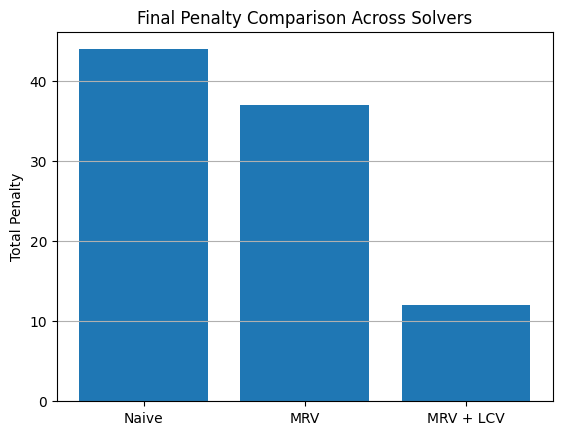

In [26]:
import matplotlib.pyplot as plt

# Replace with your actual results
solvers = ["Naive", "MRV", "MRV + LCV"]
penalties = [44, 37, 12]  

plt.figure()
plt.bar(solvers, penalties)
plt.ylabel("Total Penalty")
plt.title("Final Penalty Comparison Across Solvers")
plt.grid(axis="y")

plt.show()


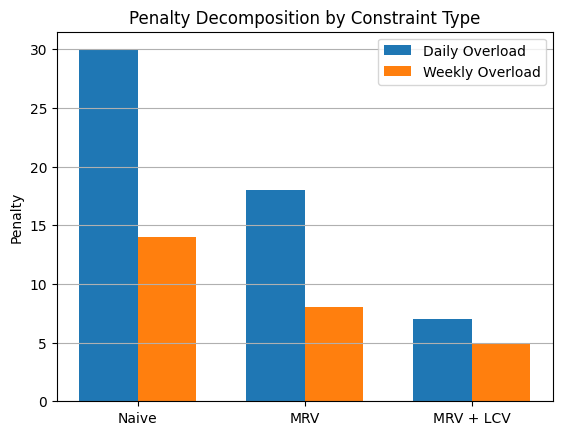

In [27]:
import matplotlib.pyplot as plt
import numpy as np

solvers = ["Naive", "MRV", "MRV + LCV"]

daily_penalty = [30, 18, 7]     # <-- adjust
weekly_penalty = [14, 8, 5]     # <-- adjust

x = np.arange(len(solvers))
width = 0.35

plt.figure()
plt.bar(x - width/2, daily_penalty, width, label="Daily Overload")
plt.bar(x + width/2, weekly_penalty, width, label="Weekly Overload")

plt.xticks(x, solvers)
plt.ylabel("Penalty")
plt.title("Penalty Decomposition by Constraint Type")
plt.legend()
plt.grid(axis="y")

plt.show()


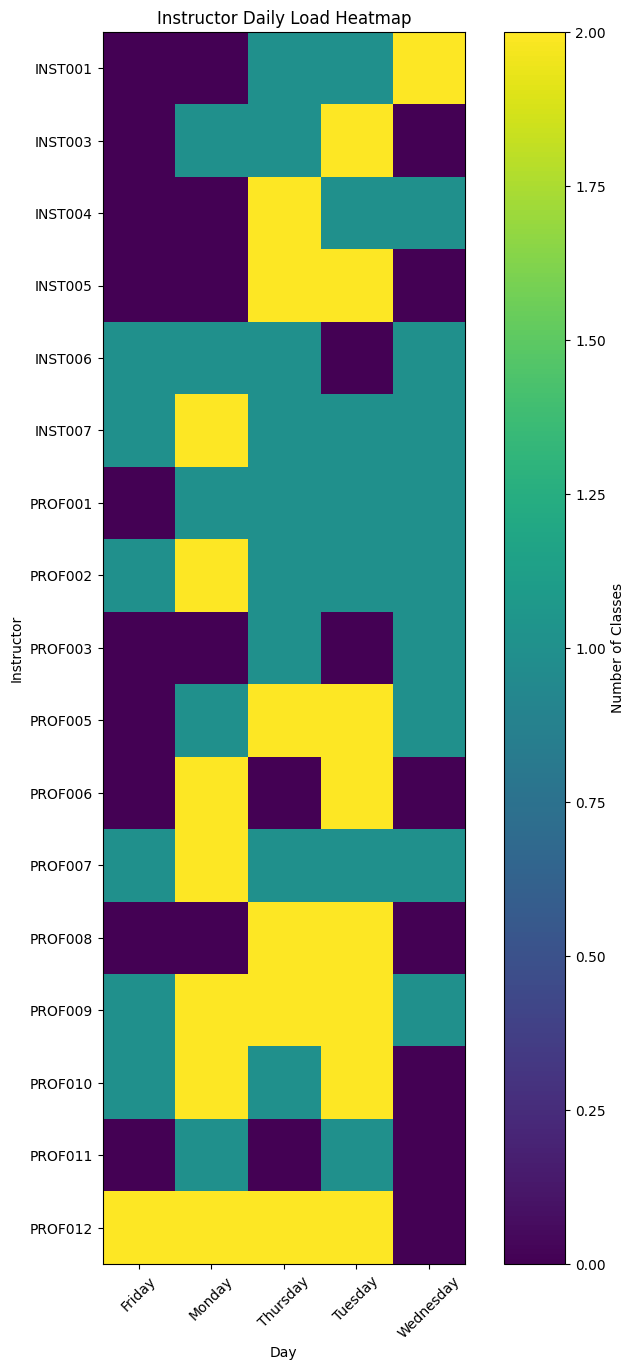

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

pivot = (
    df.groupby(["Instructor", "Day"])
      .size()
      .unstack(fill_value=0)
)

plt.figure(figsize=(10,16))
plt.imshow(pivot.values)
plt.colorbar(label="Number of Classes")

plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=45)
plt.yticks(range(len(pivot.index)), pivot.index)

plt.title("Instructor Daily Load Heatmap")
plt.xlabel("Day")
plt.ylabel("Instructor")

plt.show()


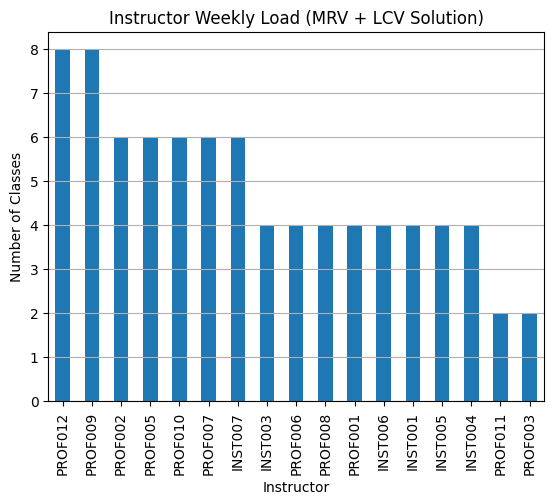

In [34]:
import matplotlib.pyplot as plt

instructor_load = df["Instructor"].value_counts()

plt.figure()
instructor_load.plot(kind="bar")
plt.ylabel("Number of Classes")
plt.title("Instructor Weekly Load (MRV + LCV Solution)")
plt.grid(axis="y")

plt.show()


In [2]:
import pandas as pd
from collections import defaultdict
import datetime
import time

# =====================================================
# CONFIG
# =====================================================
EXCEL_PATH = "FINISHDEUJE.xlsx"

SHEET_COURSES = "Courses"
SHEET_INSTRUCTOR_COURSES = "InstructorCourses"
SHEET_AVAIL = "Hard"
SHEET_ROOMS = "RoomSeatingCapacity"

DAYS = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
SLOT_STARTS = ["08:30", "10:00", "11:30", "13:00", "14:30", "16:00", "17:30"]
SLOT_DURATION_MIN = 75

DAILY_MAX_CLASSES = 2
INSTRUCTOR_WEEKLY_LIMIT = 6
PROFESSOR_WEEKLY_LIMIT = 6

TIME_LIMIT_SEC = 300

W_DAILY_EXCESS = 5
W_WEEKLY_EXCESS = 3

# =====================================================
# HELPERS
# =====================================================
def time_to_minutes(t):
    if pd.isna(t): return None
    if isinstance(t, datetime.time): return t.hour * 60 + t.minute
    if isinstance(t, datetime.datetime): return t.hour * 60 + t.minute
    hh, mm = str(t).strip().split(":")[:2]
    return int(hh) * 60 + int(mm)

def course_level(cid):
    return "master" if cid and len(cid) >= 5 and cid[4] in "56" else "bachelor"

# =====================================================
# LOAD DATA
# =====================================================
xls = pd.ExcelFile(EXCEL_PATH)
df_courses = pd.read_excel(xls, SHEET_COURSES)
df_inst_courses = pd.read_excel(xls, SHEET_INSTRUCTOR_COURSES)
df_avail = pd.read_excel(xls, SHEET_AVAIL)
df_rooms = pd.read_excel(xls, SHEET_ROOMS)

print("Loaded shapes:",
      "Courses", df_courses.shape,
      "InstructorCourses", df_inst_courses.shape,
      "Hard", df_avail.shape,
      "Rooms", df_rooms.shape)

# =====================================================
# BUILD STRUCTURES
# =====================================================
sections = []
for _, r in df_courses.iterrows():
    sections.append({
        "course_id": str(r["COURSE ID"]).strip(),
        "course_name": str(r["COURSE"]).strip(),
        "section_id": str(r["SECTION ID"]).strip(),
        "num_students": int(r["# OF STUDENTS"])
    })

SECTION_INFO = {s["section_id"]: s for s in sections}
section_ids = list(SECTION_INFO.keys())

def get_course_id(sid): return SECTION_INFO[sid]["course_id"]
def get_course_name(sid): return SECTION_INFO[sid]["course_name"]

qualified = defaultdict(set)
for _, r in df_inst_courses.iterrows():
    qualified[str(r["COURSE ID"]).strip()].add(str(r["InstructorID"]).strip())

all_instructors = set(df_inst_courses["InstructorID"].astype(str)) | set(df_avail["InstructorID"].astype(str))
instructor_role = {i: ("professor" if i.startswith("PROF") else "instructor") for i in all_instructors}

def weekly_limit(iid):
    return PROFESSOR_WEEKLY_LIMIT if instructor_role.get(iid) == "professor" else INSTRUCTOR_WEEKLY_LIMIT

rooms = [(str(r["Room ID"]).strip(), int(r["Capacity (seats)"])) for _, r in df_rooms.iterrows()]

MASTER_SECTIONS = {s["section_id"] for s in sections if course_level(s["course_id"]) == "master"}

# =====================================================
# MEETING VARIABLES
# =====================================================
MEETING_VARS = []
MEETING_TO_SECTION = {}
SECTION_TO_MEETINGS = defaultdict(list)

for sid in section_ids:
    for k in (1, 2):
        mid = f"{sid}_M{k}"
        MEETING_VARS.append(mid)
        MEETING_TO_SECTION[mid] = sid
        SECTION_TO_MEETINGS[sid].append(mid)

def base_section(mid): return MEETING_TO_SECTION[mid]

# =====================================================
# AVAILABILITY
# =====================================================
unavailable = defaultdict(list)
for _, r in df_avail.iterrows():
    if str(r["Availability Type"]).upper() == "UNAVAILABLE":
        unavailable[str(r["InstructorID"]).strip()].append(
            (str(r["Day"]).strip(),
             time_to_minutes(r["StartTime"]),
             time_to_minutes(r["EndTime"]))
        )

def instructor_available(iid, day, t):
    s = time_to_minutes(t)
    e = s + SLOT_DURATION_MIN
    for d, u1, u2 in unavailable[iid]:
        if d == day and not (e <= u1 or s >= u2):
            return False
    return True

feasible_rooms = {
    s["section_id"]: [r for (r, c) in rooms if c >= s["num_students"]]
    for s in sections
}

# =====================================================
# DOMAINS
# =====================================================
domains = {m: [] for m in MEETING_VARS}
SLOTS = [(d, t) for d in DAYS for t in SLOT_STARTS]

for s in sections:
    sid, cid = s["section_id"], s["course_id"]
    level = course_level(cid)
    instructors = list(qualified[cid])

    if level == "master":
        instructors = [i for i in instructors if instructor_role[i] == "professor"]

    for mid in SECTION_TO_MEETINGS[sid]:
        for day, t in SLOTS:
            if level == "master" and time_to_minutes(t) < time_to_minutes("16:00"):
                continue
            for room in feasible_rooms[sid]:
                for iid in instructors:
                    if instructor_available(iid, day, t):
                        domains[mid].append((day, t, room, iid))

print("Domain sizes:",
      min(len(v) for v in domains.values()),
      sum(len(v) for v in domains.values()) / len(domains),
      max(len(v) for v in domains.values()))

# =====================================================
# HARD CONSTRAINTS
# =====================================================
course_to_sections = defaultdict(list)
for s in sections:
    course_to_sections[s["course_id"]].append(s["section_id"])

def violates_two_instructor_rule(mid, iid, assignment):
    course = get_course_id(base_section(mid))
    if len(course_to_sections[course]) < 3:
        return False
    used = {assignment[m][3]
            for sec in course_to_sections[course]
            for m in SECTION_TO_MEETINGS[sec] if m in assignment}
    return iid not in used and len(used) >= 2

def violates_same_instructor(mid, iid, assignment):
    sid = base_section(mid)
    return any(m in assignment and assignment[m][3] != iid for m in SECTION_TO_MEETINGS[sid])

def violates_same_day(mid, day, assignment):
    sid = base_section(mid)
    return any(base_section(m) == sid and assignment[m][0] == day for m in assignment)

def violates_master_daily(mid, day, assignment):
    if base_section(mid) not in MASTER_SECTIONS:
        return False
    return sum(1 for m, (d,_,_,_) in assignment.items()
               if d == day and base_section(m) in MASTER_SECTIONS) >= 2

# =====================================================
# SOFT PENALTY
# =====================================================
def soft_penalty(iid, day, daily, weekly):
    p = 0
    if daily[(iid, day)] + 1 > DAILY_MAX_CLASSES:
        p += W_DAILY_EXCESS
    if weekly[iid] + 1 > weekly_limit(iid):
        p += W_WEEKLY_EXCESS
    return p

# =====================================================
# SEARCH TREE STATISTICS
# =====================================================
stats = {
    "nodes_expanded": 0,
    "max_depth": 0,
    "branching_per_depth": defaultdict(list)
}

# =====================================================
# MRV + LCV SOLVER
# =====================================================
def solve_soft():
    assignment = {}
    used_room, used_instr = set(), set()
    daily, weekly = defaultdict(int), defaultdict(int)

    best_sol = None
    best_penalty = float("inf")
    start = time.time()

    def select_mrv():
        unassigned = [m for m in MEETING_VARS if m not in assignment]
        return min(unassigned, key=lambda m: len(domains[m]))

    def lcv_order(mid):
        scored = []
        for day, t, room, iid in domains[mid]:
            if (day,t,room) in used_room: continue
            if (day,t,iid) in used_instr: continue
            if violates_same_instructor(mid,iid,assignment): continue
            if violates_same_day(mid,day,assignment): continue
            if violates_two_instructor_rule(mid,iid,assignment): continue
            if violates_master_daily(mid,day,assignment): continue

            conflicts = 0
            for other in MEETING_VARS:
                if other == mid or other in assignment:
                    continue
                for d2,t2,r2,i2 in domains[other]:
                    if d2 == day and t2 == t and (r2 == room or i2 == iid):
                        conflicts += 1
            scored.append((conflicts, (day, t, room, iid)))

        scored.sort(key=lambda x: x[0])
        return [v for _, v in scored]

    def backtrack(penalty, depth=0):
        nonlocal best_sol, best_penalty

        if time.time() - start > TIME_LIMIT_SEC:
            return
        if penalty >= best_penalty:
            return

        stats["nodes_expanded"] += 1
        stats["max_depth"] = max(stats["max_depth"], depth)

        if len(assignment) == len(MEETING_VARS):
            best_sol = assignment.copy()
            best_penalty = penalty
            return

        mid = select_mrv()
        values = lcv_order(mid)
        stats["branching_per_depth"][depth].append(len(values))

        for day, t, room, iid in values:
            addp = soft_penalty(iid, day, daily, weekly)
            if penalty + addp >= best_penalty:
                continue

            assignment[mid] = (day, t, room, iid)
            used_room.add((day,t,room))
            used_instr.add((day,t,iid))
            daily[(iid,day)] += 1
            weekly[iid] += 1

            backtrack(penalty + addp, depth + 1)

            del assignment[mid]
            used_room.remove((day,t,room))
            used_instr.remove((day,t,iid))
            daily[(iid,day)] -= 1
            weekly[iid] -= 1

    backtrack(0)
    return best_sol, best_penalty, time.time() - start

# =====================================================
# RUN
# =====================================================
print("\nRunning Agent (MRV + LCV + Soft CSP)...")
solution, penalty, elapsed = solve_soft()

print(f"\n✅ Finished in {elapsed:.2f}s")
print(f"⚠ Total penalty = {penalty}")

# =====================================================
# SEARCH TREE SUMMARY
# =====================================================
avg_branching = (
    sum(sum(v) for v in stats["branching_per_depth"].values()) /
    sum(len(v) for v in stats["branching_per_depth"].values())
)

max_branching = max(
    max(v) for v in stats["branching_per_depth"].values()
)

print("\n===== SEARCH TREE STATISTICS =====")
print(f"Nodes expanded: {stats['nodes_expanded']}")
print(f"Max depth reached: {stats['max_depth']} (theoretical max = {len(MEETING_VARS)})")
print(f"Average branching factor: {avg_branching:.2f}")
print(f"Maximum branching factor: {max_branching}")

# =====================================================
# DISPLAY FINAL SCHEDULE
# =====================================================
rows = []
for mid, (day, time_str, room, iid) in solution.items():
    sid = base_section(mid)
    rows.append({
        "Section ID": sid,
        "Meeting": mid,
        "Course ID": get_course_id(sid),
        "Course": get_course_name(sid),
        "Day": day,
        "Start Time": time_str,
        "Room": room,
        "Instructor": iid
    })

df = pd.DataFrame(rows)
df["DayOrder"] = df["Day"].map({d:i for i,d in enumerate(DAYS)})
df = df.sort_values(["DayOrder","Start Time","Course ID"]).drop(columns="DayOrder")

print("\n===== FINAL SCHEDULE =====\n")
print(df.to_string(index=False))


Loaded shapes: Courses (41, 4) InstructorCourses (36, 4) Hard (90, 5) Rooms (14, 2)
Domain sizes: 56 184.02439024390245 351

Running Agent (MRV + LCV + Soft CSP)...

✅ Finished in 300.07s
⚠ Total penalty = 12

===== SEARCH TREE STATISTICS =====
Nodes expanded: 8398
Max depth reached: 82 (theoretical max = 82)
Average branching factor: 86.11
Maximum branching factor: 254

===== FINAL SCHEDULE =====

Section ID  Meeting Course ID                                     Course       Day Start Time Room Instructor
     20613 20613_M2  CSCI2303                 Intro to Computer Networks    Monday      08:30 B201    PROF012
     20294 20294_M1  CSCI4700                                Data Mining    Monday      08:30 A102    INST003
     20317 20317_M1  CSCI2303                 Intro to Computer Networks    Monday      10:00 D108    PROF012
     20595 20595_M2  CSCI3600                Intro to Python Programming    Monday      10:00 B201    PROF009
     20596 20596_M1  CSCI3600                Int

In [9]:
import pandas as pd
from collections import defaultdict
import datetime
import time

# =====================================================
# CONFIG
# =====================================================
EXCEL_PATH = "FINISHDEUJE.xlsx"

SHEET_COURSES = "Courses"
SHEET_INSTRUCTOR_COURSES = "InstructorCourses"
SHEET_AVAIL = "Hard"
SHEET_ROOMS = "RoomSeatingCapacity"

DAYS = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
SLOT_STARTS = ["08:30", "10:00", "11:30", "13:00", "14:30", "16:00", "17:30"]
SLOT_DURATION_MIN = 75

DAILY_MAX_CLASSES = 2
INSTRUCTOR_WEEKLY_LIMIT = 6
PROFESSOR_WEEKLY_LIMIT = 6

TIME_LIMIT_SEC = 300

W_DAILY_EXCESS = 5
W_WEEKLY_EXCESS = 3

# =====================================================
# HELPERS
# =====================================================
def time_to_minutes(t):
    if pd.isna(t): return None
    if isinstance(t, datetime.time): return t.hour * 60 + t.minute
    if isinstance(t, datetime.datetime): return t.hour * 60 + t.minute
    hh, mm = str(t).strip().split(":")[:2]
    return int(hh) * 60 + int(mm)

def course_level(cid):
    return "master" if cid and len(cid) >= 5 and cid[4] in "56" else "bachelor"

# =====================================================
# LOAD DATA
# =====================================================
xls = pd.ExcelFile(EXCEL_PATH)
df_courses = pd.read_excel(xls, SHEET_COURSES)
df_inst_courses = pd.read_excel(xls, SHEET_INSTRUCTOR_COURSES)
df_avail = pd.read_excel(xls, SHEET_AVAIL)
df_rooms = pd.read_excel(xls, SHEET_ROOMS)

print("Loaded shapes:",
      "Courses", df_courses.shape,
      "InstructorCourses", df_inst_courses.shape,
      "Hard", df_avail.shape,
      "Rooms", df_rooms.shape)

# =====================================================
# BUILD STRUCTURES
# =====================================================
sections = []
for _, r in df_courses.iterrows():
    sections.append({
        "course_id": str(r["COURSE ID"]).strip(),
        "course_name": str(r["COURSE"]).strip(),
        "section_id": str(r["SECTION ID"]).strip(),
        "num_students": int(r["# OF STUDENTS"])
    })

SECTION_INFO = {s["section_id"]: s for s in sections}
section_ids = list(SECTION_INFO.keys())

def get_course_id(sid): return SECTION_INFO[sid]["course_id"]
def get_course_name(sid): return SECTION_INFO[sid]["course_name"]

qualified = defaultdict(set)
for _, r in df_inst_courses.iterrows():
    qualified[str(r["COURSE ID"]).strip()].add(str(r["InstructorID"]).strip())

all_instructors = set(df_inst_courses["InstructorID"].astype(str)) | set(df_avail["InstructorID"].astype(str))
instructor_role = {i: ("professor" if i.startswith("PROF") else "instructor") for i in all_instructors}

def weekly_limit(iid):
    return PROFESSOR_WEEKLY_LIMIT if instructor_role.get(iid) == "professor" else INSTRUCTOR_WEEKLY_LIMIT

rooms = [(str(r["Room ID"]).strip(), int(r["Capacity (seats)"])) for _, r in df_rooms.iterrows()]

MASTER_SECTIONS = {s["section_id"] for s in sections if course_level(s["course_id"]) == "master"}

# =====================================================
# MEETING VARIABLES
# =====================================================
MEETING_VARS = []
MEETING_TO_SECTION = {}
SECTION_TO_MEETINGS = defaultdict(list)

for sid in section_ids:
    for k in (1, 2):
        mid = f"{sid}_M{k}"
        MEETING_VARS.append(mid)
        MEETING_TO_SECTION[mid] = sid
        SECTION_TO_MEETINGS[sid].append(mid)

def base_section(mid): return MEETING_TO_SECTION[mid]

# =====================================================
# AVAILABILITY
# =====================================================
unavailable = defaultdict(list)
for _, r in df_avail.iterrows():
    if str(r["Availability Type"]).upper() == "UNAVAILABLE":
        unavailable[str(r["InstructorID"]).strip()].append(
            (str(r["Day"]).strip(),
             time_to_minutes(r["StartTime"]),
             time_to_minutes(r["EndTime"]))
        )

def instructor_available(iid, day, t):
    s = time_to_minutes(t)
    e = s + SLOT_DURATION_MIN
    for d, u1, u2 in unavailable[iid]:
        if d == day and not (e <= u1 or s >= u2):
            return False
    return True

# =====================================================
# DOMAINS
# =====================================================
feasible_rooms = {
    s["section_id"]: [r for (r, c) in rooms if c >= s["num_students"]]
    for s in sections
}

domains = {m: [] for m in MEETING_VARS}
SLOTS = [(d, t) for d in DAYS for t in SLOT_STARTS]

for s in sections:
    sid, cid = s["section_id"], s["course_id"]
    instructors = list(qualified[cid])

    if course_level(cid) == "master":
        instructors = [i for i in instructors if instructor_role[i] == "professor"]

    for mid in SECTION_TO_MEETINGS[sid]:
        for day, t in SLOTS:
            if course_level(cid) == "master" and time_to_minutes(t) < time_to_minutes("16:00"):
                continue
            for room in feasible_rooms[sid]:
                for iid in instructors:
                    if instructor_available(iid, day, t):
                        domains[mid].append((day, t, room, iid))

print("Domain sizes:",
      min(len(v) for v in domains.values()),
      sum(len(v) for v in domains.values()) / len(domains),
      max(len(v) for v in domains.values()))

# =====================================================
# HARD CONSTRAINTS
# =====================================================
course_to_sections = defaultdict(list)
for s in sections:
    course_to_sections[s["course_id"]].append(s["section_id"])

def violates_two_instructor_rule(mid, iid, assignment):
    course = get_course_id(base_section(mid))
    if len(course_to_sections[course]) < 3:
        return False
    used = {assignment[m][3]
            for sec in course_to_sections[course]
            for m in SECTION_TO_MEETINGS[sec] if m in assignment}
    return iid not in used and len(used) >= 2

def violates_same_instructor(mid, iid, assignment):
    sid = base_section(mid)
    return any(m in assignment and assignment[m][3] != iid for m in SECTION_TO_MEETINGS[sid])

def violates_same_day(mid, day, assignment):
    sid = base_section(mid)
    return any(base_section(m) == sid and assignment[m][0] == day for m in assignment)

def violates_master_daily(mid, day, assignment):
    if base_section(mid) not in MASTER_SECTIONS:
        return False
    return sum(1 for m,(d,_,_,_) in assignment.items()
               if d == day and base_section(m) in MASTER_SECTIONS) >= 2

# =====================================================
# SOFT PENALTY
# =====================================================
def soft_penalty(iid, day, daily, weekly):
    p = 0
    if daily[(iid, day)] + 1 > DAILY_MAX_CLASSES:
        p += W_DAILY_EXCESS
    if weekly[iid] + 1 > weekly_limit(iid):
        p += W_WEEKLY_EXCESS
    return p

# =====================================================
# SEARCH TREE STATISTICS
# =====================================================
stats = {
    "nodes_expanded": 0,
    "max_depth": 0,
    "branching_per_depth": defaultdict(list)
}

# =====================================================
# MRV SELECTION
# =====================================================
def select_mrv(assignment, used_room, used_instr):
    best_mid = None
    best_count = float("inf")

    for mid in MEETING_VARS:
        if mid in assignment:
            continue
        count = 0
        for day, t, room, iid in domains[mid]:
            if (day,t,room) in used_room: continue
            if (day,t,iid) in used_instr: continue
            if violates_same_instructor(mid,iid,assignment): continue
            if violates_same_day(mid,day,assignment): continue
            if violates_two_instructor_rule(mid,iid,assignment): continue
            if violates_master_daily(mid,day,assignment): continue
            count += 1
        if count < best_count:
            best_count = count
            best_mid = mid
        if best_count == 0:
            break
    return best_mid

# =====================================================
# SOLVER — SOFT CSP + MRV
# =====================================================
def solve_soft_mrv():
    assignment = {}
    used_room, used_instr = set(), set()
    daily, weekly = defaultdict(int), defaultdict(int)

    best_solution = None
    best_penalty = float("inf")
    start = time.time()

    def backtrack(penalty, depth=0):
        nonlocal best_solution, best_penalty

        if time.time() - start > TIME_LIMIT_SEC:
            return
        if penalty >= best_penalty:
            return

        stats["nodes_expanded"] += 1
        stats["max_depth"] = max(stats["max_depth"], depth)

        if len(assignment) == len(MEETING_VARS):
            best_penalty = penalty
            best_solution = assignment.copy()
            return

        mid = select_mrv(assignment, used_room, used_instr)
        if mid is None:
            return

        feasible_vals = []
        for day, t, room, iid in domains[mid]:
            if (day,t,room) in used_room: continue
            if (day,t,iid) in used_instr: continue
            if violates_same_instructor(mid,iid,assignment): continue
            if violates_same_day(mid,day,assignment): continue
            if violates_two_instructor_rule(mid,iid,assignment): continue
            if violates_master_daily(mid,day,assignment): continue
            feasible_vals.append((day, t, room, iid))

        stats["branching_per_depth"][depth].append(len(feasible_vals))

        for day, t, room, iid in feasible_vals:
            addp = soft_penalty(iid, day, daily, weekly)
            if penalty + addp >= best_penalty:
                continue

            assignment[mid] = (day, t, room, iid)
            used_room.add((day,t,room))
            used_instr.add((day,t,iid))
            daily[(iid,day)] += 1
            weekly[iid] += 1

            backtrack(penalty + addp, depth + 1)

            del assignment[mid]
            used_room.remove((day,t,room))
            used_instr.remove((day,t,iid))
            daily[(iid,day)] -= 1
            weekly[iid] -= 1

    backtrack(0)
    return best_solution, best_penalty, time.time() - start

# =====================================================
# RUN
# =====================================================
print("\nRunning Agent (Soft CSP + MRV)...")
solution, penalty, elapsed = solve_soft_mrv()

print(f"\n✅ Finished in {elapsed:.2f}s")
print(f"⚠ Total penalty = {penalty}")

# =====================================================
# SEARCH TREE SUMMARY
# =====================================================
avg_branching = (
    sum(sum(v) for v in stats["branching_per_depth"].values()) /
    sum(len(v) for v in stats["branching_per_depth"].values())
)

max_branching = max(
    max(v) for v in stats["branching_per_depth"].values()
)

print("\n===== SEARCH TREE STATISTICS (MRV ONLY) =====")
print(f"Nodes expanded: {stats['nodes_expanded']}")
print(f"Max depth reached: {stats['max_depth']} (theoretical max = {len(MEETING_VARS)})")
print(f"Average branching factor: {avg_branching:.2f}")
print(f"Maximum branching factor: {max_branching}")

# =====================================================
# DISPLAY FINAL SCHEDULE
# =====================================================
rows = []
for mid, (day, time_str, room, iid) in solution.items():
    sid = base_section(mid)
    rows.append({
        "Section ID": sid,
        "Meeting": mid,
        "Course ID": get_course_id(sid),
        "Course": get_course_name(sid),
        "Day": day,
        "Start Time": time_str,
        "Room": room,
        "Instructor": iid
    })

df = pd.DataFrame(rows)
df["DayOrder"] = df["Day"].map({d:i for i,d in enumerate(DAYS)})
df = df.sort_values(["DayOrder","Start Time","Course ID"]).drop(columns="DayOrder")

print("\n===== FINAL SCHEDULE =====\n")
print(df.to_string(index=False))


Loaded shapes: Courses (41, 4) InstructorCourses (36, 4) Hard (90, 5) Rooms (14, 2)
Domain sizes: 56 184.02439024390245 351

Running Agent (Soft CSP + MRV)...

✅ Finished in 300.01s
⚠ Total penalty = 37

===== SEARCH TREE STATISTICS (MRV ONLY) =====
Nodes expanded: 8062
Max depth reached: 82 (theoretical max = 82)
Average branching factor: 82.19
Maximum branching factor: 249

===== FINAL SCHEDULE =====

Section ID  Meeting Course ID                                     Course       Day Start Time Room Instructor
     20336 20336_M1  CSCI2304               Data Structures & Algorithms    Monday      08:30 B101    PROF009
     20319 20319_M1  CSCI3510              Princpls of Operating Systems    Monday      08:30 B201    INST004
     20321 20321_M1  CSCI3615                           Database Systems    Monday      08:30 A109    PROF012
     20294 20294_M1  CSCI4700                                Data Mining    Monday      08:30 B001    INST003
     20295 20295_M1  CSCI4701              

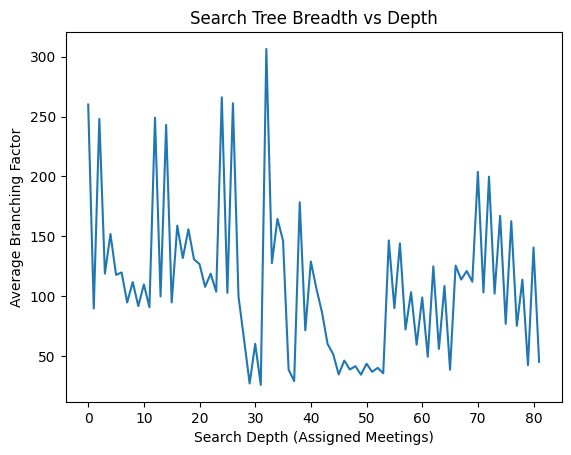

In [11]:
import matplotlib.pyplot as plt

# Compute average branching per depth
avg_branching_per_depth = {
    d: sum(v) / len(v)
    for d, v in stats["branching_per_depth"].items()
}



depths = sorted(avg_branching_per_depth.keys())
avg_b = [avg_branching_per_depth[d] for d in depths]

plt.figure()
plt.plot(depths, avg_b)
plt.xlabel("Search Depth (Assigned Meetings)")
plt.ylabel("Average Branching Factor")
plt.title("Search Tree Breadth vs Depth")
plt.show()
